# Deep Learning Systems: Fashion-MNIST Image Classification

**Task type:** image classification with a convolutional neural network (CNN). This notebook classifies 28×28 grayscale clothing images from Fashion-MNIST into ten categories. It compares a baseline CNN with an otherwise identical CNN that adds dropout regularization; dropout is the sole experimental change.

**Dataset source:** Fashion-MNIST is a public dataset of 70,000 Zalando article images (60,000 training and 10,000 test images), introduced by Xiao, Rasul, and Vollgraf (2017). The files are stored in `data/FashionMNIST/`; if absent, the loading cell documents how `torchvision` retrieves them. This dataset was selected for this project and is not reused from another capstone project.

In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, torch.get_num_threads()))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}; device: {device}")

PyTorch 2.14.0+cu130; device: cuda


## Load and inspect the data

Pixel values are converted to tensors and normalized with the training-set convention of mean 0.5 and standard deviation 0.5, placing inputs roughly in [-1, 1]. The data are already labeled and contain no missing pixel values, but the images are low-resolution and several classes are visually similar (for example, shirts, pullovers, and coats), which can create plausible errors.

In [2]:
DATA_DIR = Path("data")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
try:
    full_train = datasets.FashionMNIST(DATA_DIR, train=True, download=False, transform=transform)
    test_dataset = datasets.FashionMNIST(DATA_DIR, train=False, download=False, transform=transform)
except RuntimeError:
    print("Dataset files not found locally; downloading Fashion-MNIST via torchvision.")
    full_train = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=transform)

class_names = full_train.classes
print(f"Training images: {len(full_train):,}; test images: {len(test_dataset):,}")
print(f"Input tensor shape: {full_train[0][0].shape}; label type: {type(full_train[0][1]).__name__}")
print("Classes:", class_names)

raw_labels = full_train.targets.numpy()
counts = pd.Series(raw_labels).value_counts().sort_index()
display(pd.DataFrame({"class": class_names, "training_images": counts.values}))

Training images: 60,000; test images: 10,000
Input tensor shape: torch.Size([1, 28, 28]); label type: int
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


,class,training_images
0,T-shirt/top,6000
1,Trouser,6000
2,Pullover,6000
3,Dress,6000
4,Coat,6000
5,Sandal,6000
6,Shirt,6000
7,Sneaker,6000
8,Bag,6000
9,Ankle boot,6000


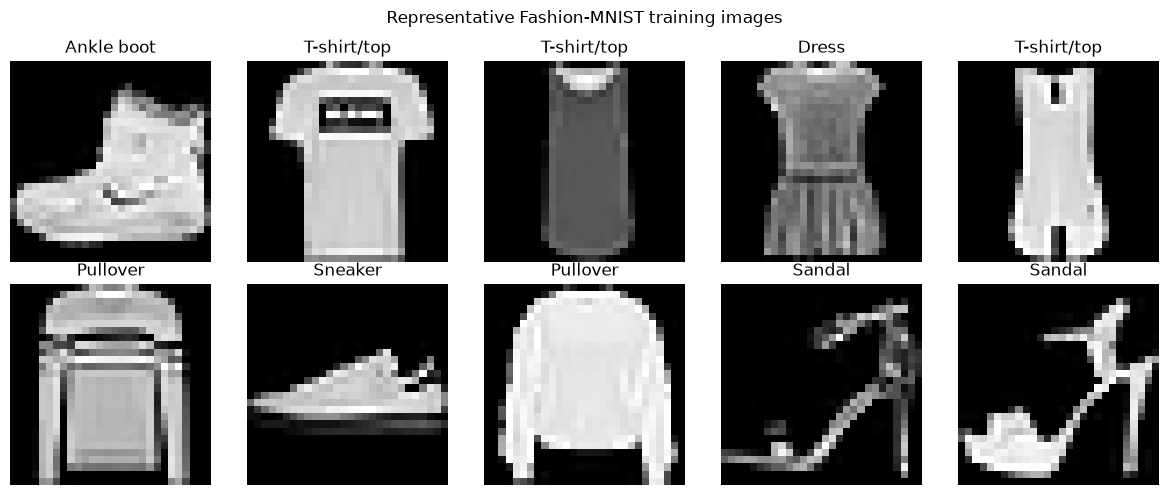

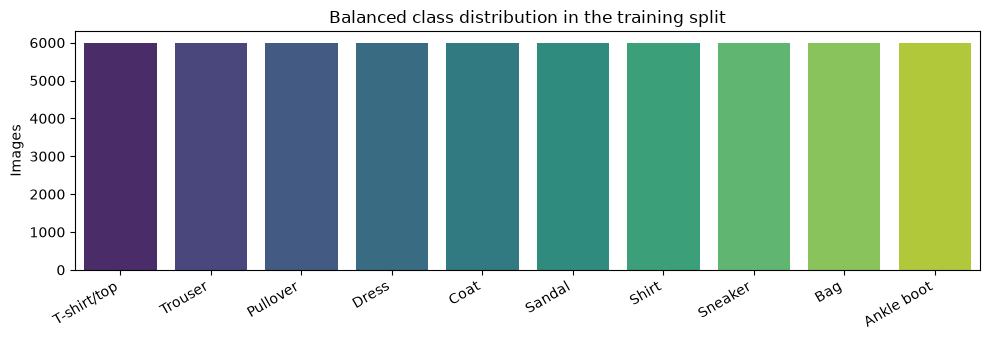

In [3]:
# Representative normalized images are rescaled only for display.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, index in zip(axes.ravel(), range(10)):
    image, label = full_train[index]
    ax.imshow(image.squeeze() * 0.5 + 0.5, cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")
fig.suptitle("Representative Fashion-MNIST training images", y=0.98)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.5))
sns.barplot(x=class_names, y=counts.values, hue=class_names, legend=False, palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Images")
plt.title("Balanced class distribution in the training split")
plt.tight_layout()
plt.show()

## Reproducible train/validation split

To keep runtime practical while retaining a substantial, stratification-free random sample, the experiment uses 4,000 training images and 1,000 validation images sampled deterministically from the original training split. The official 10,000-image test split remains untouched until final evaluation. Both configurations use the same split, seed, optimizer, learning rate, batch size, epoch count, and evaluation code.

In [4]:
experiment_train_size = 4_000
validation_size = 1_000
unused_size = len(full_train) - experiment_train_size - validation_size
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, validation_dataset, _ = random_split(
    full_train, [experiment_train_size, validation_size, unused_size], generator=split_generator
)
BATCH_SIZE = 128
loader_kwargs = {"batch_size": BATCH_SIZE, "num_workers": 0, "pin_memory": device.type == "cuda"}
train_loader = DataLoader(train_dataset, shuffle=True, generator=torch.Generator().manual_seed(SEED), **loader_kwargs)
validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)
print(f"Experiment split: {len(train_dataset):,} train / {len(validation_dataset):,} validation / {len(test_dataset):,} test")

Experiment split: 4,000 train / 1,000 validation / 10,000 test


## Model and training procedure

Convolutions learn local spatial patterns such as edges and textures while max pooling reduces spatial resolution; these inductive biases make a CNN appropriate for images (LeCun et al., 1998). The final layer emits ten unnormalized class scores (logits), so `CrossEntropyLoss` is the appropriate multi-class loss. Adam is used with a fixed learning rate of 0.001 (Kingma & Ba, 2015).

The baseline has no dropout. The experimental model changes **only** `dropout_probability` from 0.0 to 0.30. All layers remain present in both configurations, making this a controlled regularization comparison rather than an architecture comparison.

In [5]:
class FashionCNN(nn.Module):
    def __init__(self, dropout_probability=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(),
            nn.Dropout(dropout_probability), nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

def accuracy_from_loader(model, loader, criterion):
    model.eval()
    loss_total, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss_total += criterion(logits, labels).item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return loss_total / total, correct / total

def train_model(name, dropout_probability, epochs=6, learning_rate=1e-3):
    torch.manual_seed(SEED)  # identical initialization for a fair comparison
    model = FashionCNN(dropout_probability).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"epoch": [], "train_loss": [], "validation_loss": [], "train_accuracy": [], "validation_accuracy": []}
    started = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
        validation_loss, validation_accuracy = accuracy_from_loader(model, validation_loader, criterion)
        history["epoch"].append(epoch)
        history["train_loss"].append(running_loss / total)
        history["validation_loss"].append(validation_loss)
        history["train_accuracy"].append(correct / total)
        history["validation_accuracy"].append(validation_accuracy)
        print(f"{name:17} | epoch {epoch}/{epochs} | train loss {history['train_loss'][-1]:.4f}, acc {history['train_accuracy'][-1]:.3f} | val loss {validation_loss:.4f}, acc {validation_accuracy:.3f}")
    print(f"{name} completed in {time.perf_counter() - started:.1f} seconds")
    return model, pd.DataFrame(history)

In [6]:
EPOCHS = 10
baseline_model, baseline_history = train_model("Baseline (no dropout)", dropout_probability=0.0, epochs=EPOCHS)
dropout_model, dropout_history = train_model("Dropout CNN (p=0.30)", dropout_probability=0.30, epochs=EPOCHS)

Baseline (no dropout) | epoch 1/10 | train loss 1.2289, acc 0.573 | val loss 0.6983, acc 0.739


Baseline (no dropout) | epoch 2/10 | train loss 0.6482, acc 0.754 | val loss 0.5837, acc 0.801


Baseline (no dropout) | epoch 3/10 | train loss 0.5624, acc 0.790 | val loss 0.5703, acc 0.771


Baseline (no dropout) | epoch 4/10 | train loss 0.5193, acc 0.805 | val loss 0.4967, acc 0.822


Baseline (no dropout) | epoch 5/10 | train loss 0.4691, acc 0.822 | val loss 0.4863, acc 0.828


...

Dropout CNN (p=0.30) | epoch 6/10 | train loss 0.4792, acc 0.827 | val loss 0.4746, acc 0.836


Dropout CNN (p=0.30) | epoch 7/10 | train loss 0.4425, acc 0.835 | val loss 0.4348, acc 0.846


Dropout CNN (p=0.30) | epoch 8/10 | train loss 0.4130, acc 0.838 | val loss 0.4349, acc 0.848


Dropout CNN (p=0.30) | epoch 9/10 | train loss 0.3988, acc 0.854 | val loss 0.4195, acc 0.844


Dropout CNN (p=0.30) | epoch 10/10 | train loss 0.3805, acc 0.851 | val loss 0.4159, acc 0.843
Dropout CNN (p=0.30) completed in 9.5 seconds


## Training curves and controlled comparison

The plots below provide training behavior evidence. A widening gap between training and validation metrics is evidence of overfitting; a smaller gap for the dropout model would support the intended regularization effect (Srivastava et al., 2014).

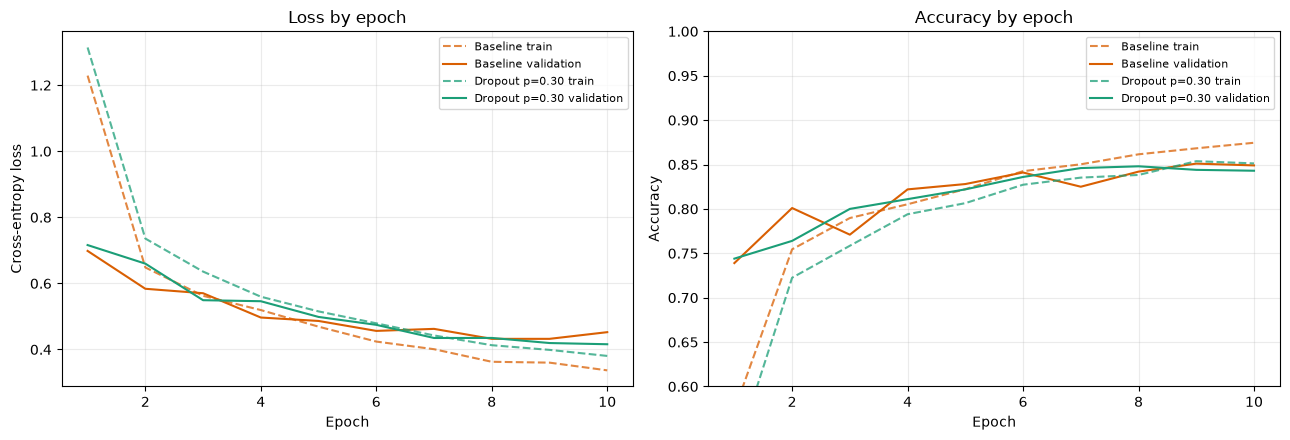

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for history, label, color in [(baseline_history, "Baseline", "#d95f02"), (dropout_history, "Dropout p=0.30", "#1b9e77")]:
    axes[0].plot(history.epoch, history.train_loss, "--", color=color, alpha=0.75, label=f"{label} train")
    axes[0].plot(history.epoch, history.validation_loss, "-", color=color, label=f"{label} validation")
    axes[1].plot(history.epoch, history.train_accuracy, "--", color=color, alpha=0.75, label=f"{label} train")
    axes[1].plot(history.epoch, history.validation_accuracy, "-", color=color, label=f"{label} validation")
axes[0].set(title="Loss by epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[1].set(title="Accuracy by epoch", xlabel="Epoch", ylabel="Accuracy", ylim=(0.6, 1.0))
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Final test evaluation

Accuracy summarizes the share of correctly classified images. The confusion matrix and per-class recall add diagnostic detail: they reveal whether a model achieves an apparently good average while systematically confusing particular garment categories.

In [8]:
def predictions_from_loader(model, loader):
    model.eval()
    actual, predicted, images_out = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))
            actual.extend(labels.numpy())
            predicted.extend(logits.argmax(dim=1).cpu().numpy())
            images_out.extend(images.numpy())
    return np.asarray(actual), np.asarray(predicted), np.asarray(images_out)

criterion = nn.CrossEntropyLoss()
baseline_test_loss, baseline_test_accuracy = accuracy_from_loader(baseline_model, test_loader, criterion)
dropout_test_loss, dropout_test_accuracy = accuracy_from_loader(dropout_model, test_loader, criterion)
y_true, baseline_pred, _ = predictions_from_loader(baseline_model, test_loader)
_, dropout_pred, test_images = predictions_from_loader(dropout_model, test_loader)

results = pd.DataFrame([
    {"model": "Baseline CNN (dropout=0.00)", "test_loss": baseline_test_loss, "test_accuracy": baseline_test_accuracy},
    {"model": "Dropout CNN (dropout=0.30)", "test_loss": dropout_test_loss, "test_accuracy": dropout_test_accuracy},
])
results["test_accuracy"] = results["test_accuracy"].map("{:.2%}".format)
results["test_loss"] = results["test_loss"].map("{:.4f}".format)
display(results)

,model,test_loss,test_accuracy
0,Baseline CNN (dropout=0.00),0.4393,84.19%
1,Dropout CNN (dropout=0.30),0.4257,84.36%


,class,recall,test_examples
0,T-shirt/top,86.90%,1000
1,Trouser,96.50%,1000
2,Pullover,74.20%,1000
3,Dress,74.10%,1000
4,Coat,72.70%,1000
5,Sandal,94.70%,1000
6,Shirt,60.50%,1000
7,Sneaker,94.00%,1000
8,Bag,96.30%,1000
9,Ankle boot,93.70%,1000


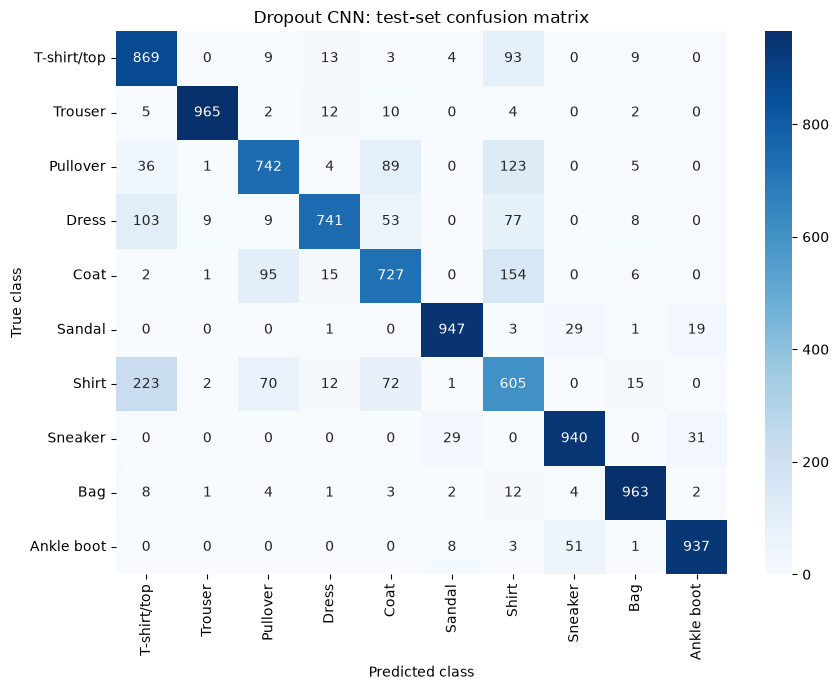

In [9]:
def confusion_matrix(actual, predicted, n_classes=10):
    matrix = np.zeros((n_classes, n_classes), dtype=int)
    np.add.at(matrix, (actual, predicted), 1)
    return matrix

cm = confusion_matrix(y_true, dropout_pred)
recall = np.diag(cm) / cm.sum(axis=1)
per_class = pd.DataFrame({"class": class_names, "recall": recall, "test_examples": cm.sum(axis=1)})
display(per_class.style.format({"recall": "{:.2%}"}))

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Dropout CNN: test-set confusion matrix")
plt.tight_layout()
plt.show()

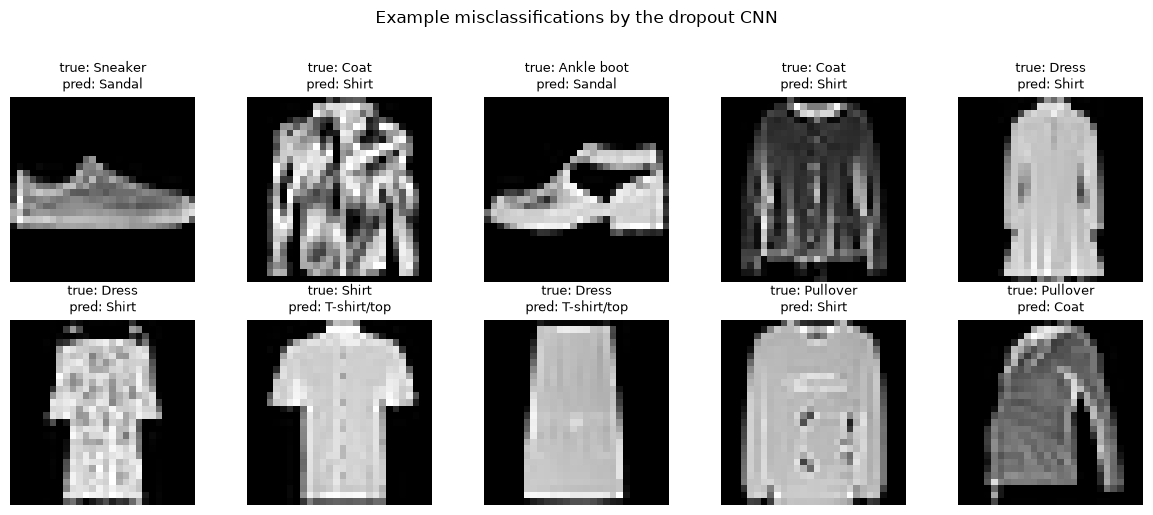

,true,predicted,count
0,Shirt,T-shirt/top,223
1,Coat,Shirt,154
2,Pullover,Shirt,123
3,Dress,T-shirt/top,103
4,Coat,Pullover,95
5,T-shirt/top,Shirt,93
6,Pullover,Coat,89
7,Dress,Shirt,77


In [10]:
# Show concrete failure cases from the experimental model.
errors = np.flatnonzero(y_true != dropout_pred)[:10]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, index in zip(axes.ravel(), errors):
    ax.imshow(test_images[index].squeeze() * 0.5 + 0.5, cmap="gray")
    ax.set_title(f"true: {class_names[y_true[index]]}\npred: {class_names[dropout_pred[index]]}", fontsize=9)
    ax.axis("off")
fig.suptitle("Example misclassifications by the dropout CNN", y=1.02)
plt.tight_layout()
plt.show()

error_pairs = pd.DataFrame({"true": [class_names[i] for i in y_true[y_true != dropout_pred]], "predicted": [class_names[i] for i in dropout_pred[y_true != dropout_pred]]})
display(error_pairs.value_counts().head(8).rename("count").reset_index())

## Notebook summary

This project used Fashion-MNIST, a real public image dataset, to classify ten clothing categories with a PyTorch CNN. The baseline used two convolution/pooling blocks and a fully connected classifier, while the experiment changed only the dropout probability from 0.00 to 0.30. The final results table and training curves quantify the test-accuracy and validation-behavior trade-off rather than relying on a single accuracy value. The confusion matrix and displayed errors show whether visually related upper-body garments remain the most difficult categories. A practical challenge is that this deliberately compact CPU experiment uses a subset of the available training images, so its result is an honest baseline rather than a production-quality benchmark. Future work could train on all 60,000 images, tune augmentation and learning-rate scheduling, and evaluate robustness on different retail-image conditions.

## References

- LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278–2324. https://doi.org/10.1109/5.726791
- Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *International Conference on Learning Representations*. https://arxiv.org/abs/1412.6980
- Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*, 1929–1958. https://jmlr.org/papers/v15/srivastava14a.html
- Xiao, H., Rasul, K., & Vollgraf, R. (2017). Fashion-MNIST: A novel image dataset for benchmarking machine learning algorithms. arXiv. https://arxiv.org/abs/1708.07747